In [1]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import geopandas as gpd
from glob import glob 

In [2]:
files = sorted(glob("./09_01_2025/wrf_outputs/wrfout_d01*"))

ds = xr.open_mfdataset(
    files,
    concat_dim="Time",
    combine="nested",
    engine="netcdf4"
)

In [3]:
list(ds.data_vars)

['Times',
 'LU_INDEX',
 'ZNU',
 'ZNW',
 'ZS',
 'DZS',
 'VAR_SSO',
 'BATHYMETRY_FLAG',
 'U',
 'V',
 'W',
 'PH',
 'PHB',
 'T',
 'THM',
 'HFX_FORCE',
 'LH_FORCE',
 'TSK_FORCE',
 'HFX_FORCE_TEND',
 'LH_FORCE_TEND',
 'TSK_FORCE_TEND',
 'MU',
 'MUB',
 'NEST_POS',
 'P',
 'PB',
 'FNM',
 'FNP',
 'RDNW',
 'RDN',
 'DNW',
 'DN',
 'CFN',
 'CFN1',
 'THIS_IS_AN_IDEAL_RUN',
 'P_HYD',
 'Q2',
 'T2',
 'TH2',
 'PSFC',
 'U10',
 'V10',
 'RDX',
 'RDY',
 'AREA2D',
 'DX2D',
 'RESM',
 'ZETATOP',
 'CF1',
 'CF2',
 'CF3',
 'ITIMESTEP',
 'QVAPOR',
 'QCLOUD',
 'QRAIN',
 'QICE',
 'QSNOW',
 'QGRAUP',
 'SHDMAX',
 'SHDMIN',
 'SHDAVG',
 'SNOALB',
 'TSLB',
 'SMOIS',
 'SH2O',
 'SMCREL',
 'SEAICE',
 'XICEM',
 'SFROFF',
 'UDROFF',
 'IVGTYP',
 'ISLTYP',
 'VEGFRA',
 'GRDFLX',
 'ACGRDFLX',
 'ACSNOM',
 'SNOW',
 'SNOWH',
 'CANWAT',
 'SSTSK',
 'WATER_DEPTH',
 'COSZEN',
 'LAI',
 'DTAUX3D',
 'DTAUY3D',
 'DUSFCG',
 'DVSFCG',
 'VAR',
 'CON',
 'OA1',
 'OA2',
 'OA3',
 'OA4',
 'OL1',
 'OL2',
 'OL3',
 'OL4',
 'O3_GFS_DU',
 'MAPFAC_M',
 'M

In [4]:
var = input("Enter the variable name you want to check: ").upper().strip()

if var in ds.data_vars:
    desc = ds[var].attrs.get('description', 'No description available.')
    dims = ds[var].dims
    print(f"Variable: '{var}' - Description: '{desc}' - Dimensions: '{dims}' has been found.")
else:
    print(f"Variable '{var}' not found in the dataset.")

Variable 'TE' not found in the dataset.


In [5]:
lat = ds['XLAT'].isel(Time=0)
lon = ds['XLONG'].isel(Time=0)

In [17]:
kenya = gpd.read_file("./ke.json")
print(kenya.columns)

Index(['source', 'id', 'name', 'geometry'], dtype='object')


In [7]:

pressure = ds['P'].isel(Time=0, bottom_top=0)  # Selecting the first time step
base_pressure = ds['PB'].isel(Time=0, bottom_top=0)  # Selecting the first time step
total_pressure = pressure + base_pressure

print(total_pressure)


<xarray.DataArray (south_north: 119, west_east: 119)> Size: 57kB
dask.array<add, shape=(119, 119), dtype=float32, chunksize=(60, 60), chunktype=numpy.ndarray>
Coordinates:
    XLAT     (south_north, west_east) float32 57kB dask.array<chunksize=(60, 60), meta=np.ndarray>
    XLONG    (south_north, west_east) float32 57kB dask.array<chunksize=(60, 60), meta=np.ndarray>
    XTIME    datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east


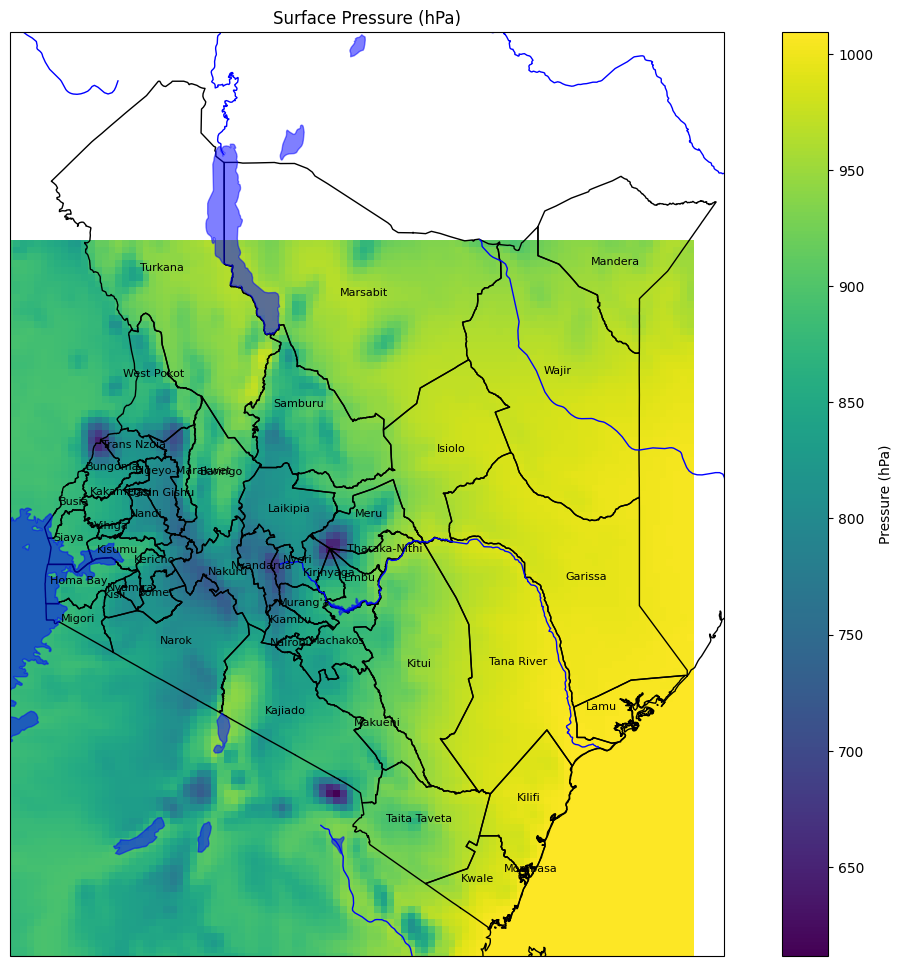

In [19]:
plt.figure(figsize=(15, 12))
ax = plt.axes(projection=ccrs.PlateCarree())


mesh = ax.pcolormesh(
    lon,
    lat,
    total_pressure / 100,  # Convert to hPa
    cmap='viridis',
    shading='auto',
    transform=ccrs.PlateCarree()
)

kenya.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

for _idx, row in kenya.iterrows():
    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["name"],
        horizontalalignment='center',
        fontsize=8,
        transform=ccrs.PlateCarree()
    )


ax.set_extent([33.5, 42, -5, 6], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(ccrs.cartopy.feature.LAKES, alpha=0.5, color='blue')
ax.add_feature(ccrs.cartopy.feature.RIVERS, edgecolor='blue')

plt.title('Surface Pressure (hPa)')
plt.colorbar(mesh, ax=ax, orientation='vertical', label='Pressure (hPa)')
plt.show()

In [9]:
wind_speed = np.sqrt(ds['U10']**2 + ds['V10']**2).isel(Time=0)

print(wind_speed.shape)

(119, 119)


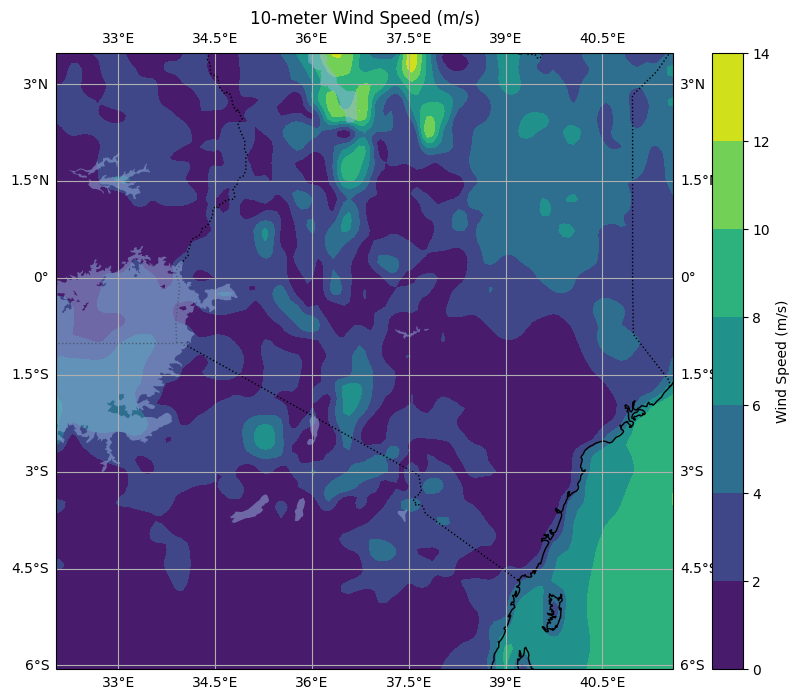

In [10]:
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
contour = ax.contourf(
    lon,
    lat,
    wind_speed
)

plt.title('10-meter Wind Speed (m/s)')
plt.colorbar(contour, ax=ax, orientation='vertical', label='Wind Speed (m/s)')
ax.coastlines() 
ax.gridlines(draw_labels=True)
ax.add_feature(ccrs.cartopy.feature.BORDERS, linestyle=':') 
ax.add_feature(ccrs.cartopy.feature.LAKES, alpha=0.5)
plt.show()

In [11]:
wind_direc = (270 - np.degrees(np.arctan2(ds['V10'], ds['U10']))).isel(Time=0) % 360
print(wind_direc.shape)

(119, 119)


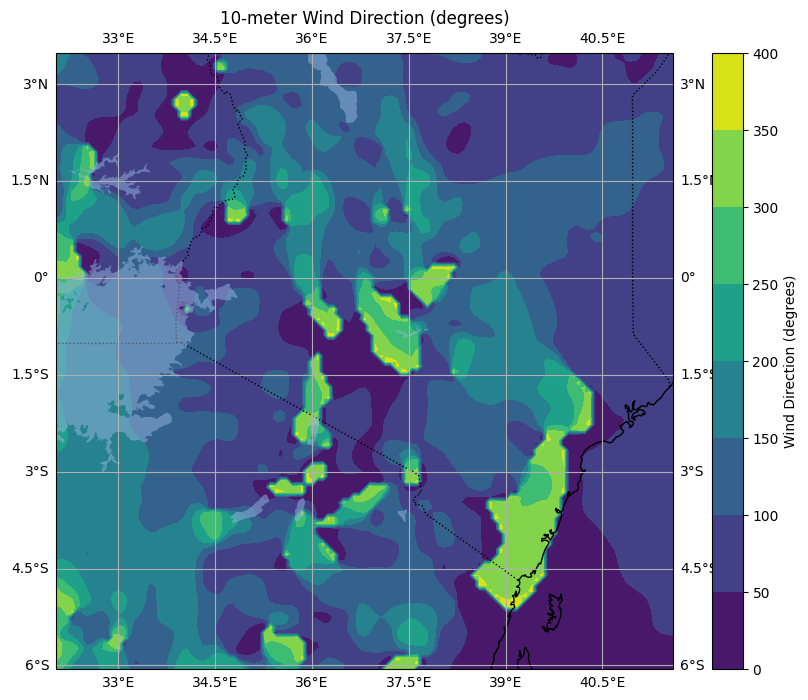

In [12]:
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
contour = ax.contourf(
    lon,    
    lat,
    wind_direc
)

plt.title('10-meter Wind Direction (degrees)')
plt.colorbar(contour, ax=ax, orientation='vertical', label='Wind Direction (degrees)')
ax.coastlines() 
ax.gridlines(draw_labels=True)
ax.add_feature(ccrs.cartopy.feature.BORDERS, linestyle=':') 
ax.add_feature(ccrs.cartopy.feature.LAKES, alpha=0.5)   
plt.show()